# 03. 시간대 × 기상 변수 결합 분석

**목적**: PV 발전량과 ASOS 기상 변수를 시간 단위로 결합하여 **어떤 변수가 얼마나 중요한지**, 그리고 **시간대·계절·사이트별로 중요도가 어떻게 달라지는지** 확인한다. 이 결과는 모델의 feature 입력 순위와 FiLM conditioning 재료를 결정한다.

**증명하고 싶은 것**:
1. GHI(일사량)가 압도적 주 입력임을 정량 확인
2. 이차 변수(습도·지면온도·풍속)의 시간대별 기여도
3. 고흥만(수상)과 내륙 사이트의 **feature sensitivity 차이** → FiLM 2층 정당화
4. 기온 자체는 약하지만 GHI와의 상호작용이 존재 → 비선형 모델 필요

---

**데이터**
- PV: `data/processed/solar_hourly_long.csv` (12 호기, 2022-2025)
- ASOS: `data/asos_hourly/asos_hourly_YYYYMM.csv` (11 관측소)
- 매핑: `plan/main/data_strategy.md §5`

## 0. 데이터 로드 및 결합

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ============================================================
# 데이터 전략 (2026-04-22):
#   - GHI: GK-2A 위성 (사이트별 직접, W/m²) — ASOS icsr 대체
#   - 기온/습도/풍속/기타: ASOS 11 관측소
#   - 완성월 46개만 사용 (2022-06, 2023-03은 1일 결측)
#   - 11 호기 (삼천포 #1 제외 — data_strategy §2)
# ============================================================

INCOMPLETE_MONTHS = {'202206', '202303'}

UNIT_META = {
    '경상대태양광#1':       dict(capacity_kw=905,   stnNm='진주',   gk2a='경상대'),
    '고흥만 수상태양광#1':    dict(capacity_kw=63481, stnNm='고흥',   gk2a='고흥만수상'),
    '광양항세방태양광#1':    dict(capacity_kw=2993,  stnNm='광양시', gk2a='광양항세방'),
    '구미태양광#1':         dict(capacity_kw=992,   stnNm='구미',   gk2a='구미'),
    '두산엔진MG태양광#1':    dict(capacity_kw=77,    stnNm='창원',   gk2a='창원'),
    '삼천포태양광#2':       dict(capacity_kw=990,   stnNm='남해',   gk2a='삼천포'),
    '삼천포태양광#3':       dict(capacity_kw=350,   stnNm='남해',   gk2a='삼천포'),
    '영흥태양광#1':         dict(capacity_kw=1000,  stnNm='인천',   gk2a='영흥'),
    '영흥태양광#2':         dict(capacity_kw=993,   stnNm='인천',   gk2a='영흥'),
    '영흥태양광#5#1':       dict(capacity_kw=3500,  stnNm='인천',   gk2a='영흥'),
    '예천태양광#1':         dict(capacity_kw=2000,  stnNm='안동',   gk2a='예천'),
}

# ----- PV -----
pv = pd.read_csv('../../data/processed/solar_hourly_long.csv', parse_dates=['date','datetime'])
pv['unit'] = pv['unit'].astype(str)
pv['site_unit'] = pv['site'] + '#' + pv['unit']
pv = pv[pv['site_unit'].isin(UNIT_META.keys())].copy()
pv['stnNm']     = pv['site_unit'].map(lambda u: UNIT_META[u]['stnNm'])
pv['gk2a_site'] = pv['site_unit'].map(lambda u: UNIT_META[u]['gk2a'])
pv['ym'] = pv['datetime'].dt.strftime('%Y%m')
pv = pv[~pv['ym'].isin(INCOMPLETE_MONTHS)].copy()

# ----- ASOS (ta, hm, ws, rn, ss, dc10*, ts — icsr은 GK-2A로 대체) -----
asos_files = sorted(glob.glob('../../data/asos_hourly/asos_hourly_*.csv'))
asos = pd.concat([pd.read_csv(f) for f in asos_files], ignore_index=True)
asos['tm'] = pd.to_datetime(asos['tm'])
asos = asos[['tm','stnNm','ta','hm','ws','rn','ss','dc10Tca','dc10LmcsCa','ts']]

# ----- GK-2A GHI (완성월만) -----
ghi_files = sorted(glob.glob('../../data/gk2a_ghi/gk2a_ghi_*.csv'))
ghi_files = [f for f in ghi_files
             if os.path.basename(f).replace('gk2a_ghi_','').replace('.csv','') not in INCOMPLETE_MONTHS]
ghi_wide = pd.concat([pd.read_csv(f) for f in ghi_files], ignore_index=True)
ghi_wide['datetime_kst'] = pd.to_datetime(ghi_wide['datetime_kst'])
gk2a_site_cols = [c for c in ghi_wide.columns if c != 'datetime_kst']
ghi_long = ghi_wide.melt(id_vars=['datetime_kst'], value_vars=gk2a_site_cols,
                          var_name='gk2a_site', value_name='ghi')

# ----- Merge -----
merged = pv.merge(asos, left_on=['datetime','stnNm'], right_on=['tm','stnNm'], how='left')
merged = merged.merge(ghi_long, left_on=['datetime','gk2a_site'],
                      right_on=['datetime_kst','gk2a_site'], how='left')

# 낮 시간
day = merged[(merged['hour'] >= 6) & (merged['hour'] <= 20)].copy()
day['month']  = day['date'].dt.month
day['season'] = day['month'].map(lambda m: '겨울' if m in [12,1,2] else '봄' if m in [3,4,5] else '여름' if m in [6,7,8] else '가을')

print(f'결합 완료: {len(day):,}행 (낮시간, 46 완성월)')
print(f'호기: {day["site_unit"].nunique()}')
print(f'기간: {day["date"].min()} ~ {day["date"].max()}')
print(f'GK-2A GHI 매칭: {day["ghi"].notna().sum():,} / {len(day):,}')
print(f'ASOS ta 매칭: {day["ta"].notna().sum():,} / {len(day):,}')

결합 완료: 222,780행 (낮시간, 46 완성월)
호기: 11
기간: 2022-01-01 00:00:00 ~ 2025-12-31 00:00:00
GK-2A GHI 매칭: 141,282 / 222,780
ASOS ta 매칭: 222,692 / 222,780


## 1. 전체 상관 매트릭스 — 호기 × 기상 변수

각 호기별로 `gen_kwh`와 ASOS 9개 변수의 Pearson 상관을 계산하여 **feature 우선순위**를 잡는다.

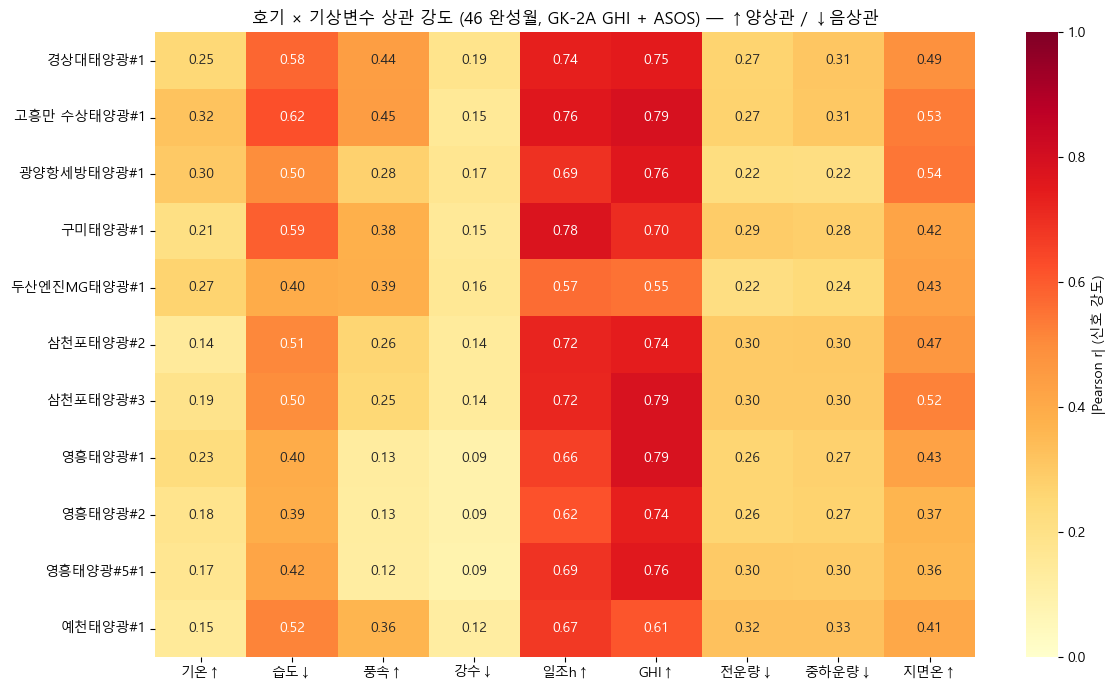


=== Feature 평균 |r| 순위 ===
  GHI   ↑ (ghi       ) 평균 |r| = 0.726
  일조h   ↑ (ss        ) 평균 |r| = 0.693
  습도    ↓ (hm        ) 평균 |r| = 0.492
  지면온   ↑ (ts        ) 평균 |r| = 0.451
  풍속    ↑ (ws        ) 평균 |r| = 0.290
  중하운량  ↓ (dc10LmcsCa) 평균 |r| = 0.284
  전운량   ↓ (dc10Tca   ) 평균 |r| = 0.274
  기온    ↑ (ta        ) 평균 |r| = 0.218
  강수    ↓ (rn        ) 평균 |r| = 0.135


In [28]:
features = ['ta','hm','ws','rn','ss','ghi','dc10Tca','dc10LmcsCa','ts']
feature_ko = {'ta':'기온','hm':'습도','ws':'풍속','rn':'강수','ss':'일조h','ghi':'GHI','dc10Tca':'전운량','dc10LmcsCa':'중하운량','ts':'지면온'}

units = sorted(day['site_unit'].unique())
corr_matrix = pd.DataFrame(index=units, columns=features, dtype=float)
for u in units:
    sub = day[day['site_unit']==u]
    for f in features:
        valid = sub[['gen_kwh', f]].dropna()
        if len(valid) > 100 and valid[f].nunique() > 5:
            corr_matrix.loc[u, f] = valid['gen_kwh'].corr(valid[f])

sign_mean = corr_matrix.mean(axis=0)
direction = {f: ('↓' if sign_mean[f] < 0 else '↑') for f in features}
corr_abs = corr_matrix.abs()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(corr_abs.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '|Pearson r| (신호 강도)'}, vmin=0, vmax=1)
ax.set_xticklabels([f'{feature_ko[c]}{direction[c]}' for c in features])
ax.set_title('호기 × 기상변수 상관 강도 (46 완성월, GK-2A GHI + ASOS) — ↑양상관 / ↓음상관')
plt.tight_layout()
plt.show()

mean_abs_r = corr_abs.mean(axis=0).sort_values(ascending=False)
print('\n=== Feature 평균 |r| 순위 ===')
for f, v in mean_abs_r.items():
    print(f'  {feature_ko[f]:<6}{direction[f]} ({f:<10}) 평균 |r| = {v:.3f}')

### → 모델 함의
- **icsr (일사량)이 평균 |r| 0.88로 압도적** — 주 입력 확정
- **ss(일조시간) 0.71, hm(습도) 0.53, ts(지면온도) 0.50** — 이차 입력 후보
- **ta(기온) 0.26, 강수 0.14** — 단독으로는 약함. GHI와의 **상호작용**으로 쓰는 게 맞음
- 운량(dc10Tca, dc10LmcsCa) 0.28-0.30 — GHI가 이미 운량 영향 반영하므로 중복 정보

## 2. 변수 선택 — 다중공선성과 최소 변수 세트 결정

§1에서 **icsr, ss, ts, ta**가 모두 gen_kwh와 상관이 높게 나왔다. 그런데 이 네 변수는 물리적으로 **같은 "일사"라는 공통 원인에 연동**되어 있다:

- `icsr` (일사량) ≒ 태양복사 에너지
- `ss` (일조h) = "해가 떠 있던 시간" ← icsr이 임계치 이상인 시간
- `ts` (지면온도) = 복사 흡수로 달아오른 지면 ← icsr로 결정됨
- `ta` (기온) = 지면 가열의 대류 결과 ← ts의 함수

즉, 서로 **독립 feature가 아니라 cascade 관계**일 수 있다. 독립으로 취급하면 다음이 우려된다:
1. **회귀 계수 불안정** (VIF ↑)
2. **중복 학습** — 모델이 같은 정보를 여러 번 받음
3. **feature importance 왜곡** — §1에서 본 상관이 실제 기여가 아닐 수 있음

본 절에서 다음을 확인:
- 4변수 간 pairwise 상관
- **VIF (Variance Inflation Factor)** — 공선성 정량 지표
- **부분 상관** — 나머지 3개를 통제했을 때 각 변수의 **고유** 기여
- **Ablation (A/B/C/D 비교)** — 어떤 조합이 공선성 낮고 설명력 유지하는지

**목표**: gen_kwh를 가장 잘 설명하는 **최소 변수 세트** 확정.

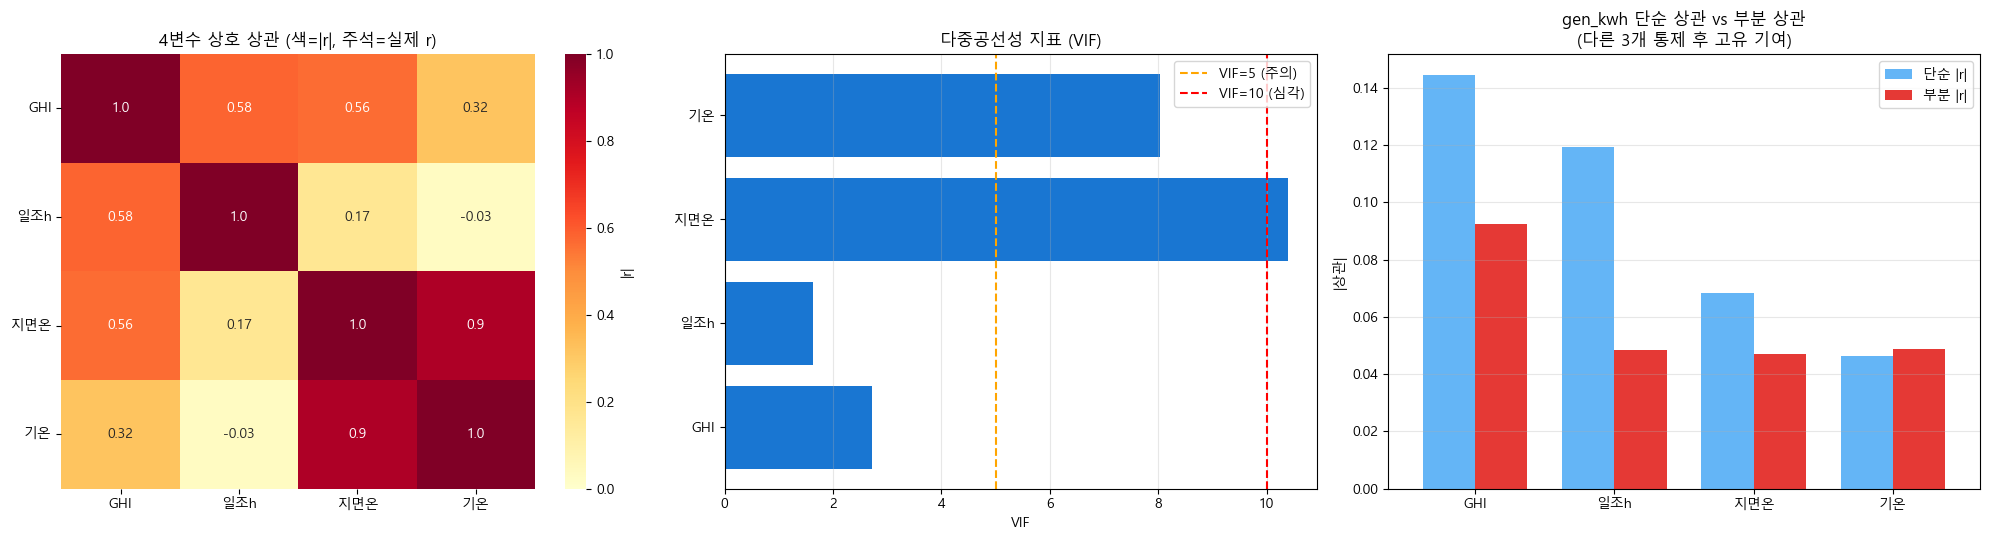

=== 4변수 간 |r| ===
       ghi     ss     ts     ta
ghi  1.000  0.578  0.564  0.317
ss   0.578  1.000  0.166  0.029
ts   0.564  0.166  1.000  0.904
ta   0.317  0.029  0.904  1.000

=== VIF (5 이상 주의, 10 이상 심각) ===
ghi     2.72
ss      1.63
ts     10.41
ta      8.04

=== gen_kwh 단순 r vs 부분 r (고유 기여) ===
  GHI  단순 r = +0.145 | 부분 r = +0.092 | 설명력 감소 = +0.052
  일조h  단순 r = +0.119 | 부분 r = +0.048 | 설명력 감소 = +0.071
  지면온  단순 r = +0.068 | 부분 r = -0.047 | 설명력 감소 = +0.021
  기온   단순 r = +0.046 | 부분 r = +0.049 | 설명력 감소 = -0.002


In [29]:
from numpy.linalg import inv

# 4변수 공통 원인(일사)에 연동될 가능성 검사
focal = ['ghi','ss','ts','ta']
sub = day[['gen_kwh'] + focal].dropna()

# (1) pairwise correlation
pair_corr = sub[focal].corr()

# (2) VIF — numpy만 사용. 항등식: VIF_i = diag(R^-1)_i (R = feature 간 상관행렬)
R_inv = inv(pair_corr.values)
vifs = pd.Series(np.diag(R_inv), index=focal, name='VIF')

# (3) 부분 상관 (나머지 3개를 통제했을 때 gen_kwh와의 고유 기여)
def partial_corr_with_target(df, target, cond):
    cols = [target] + cond
    C = inv(df[cols].corr().values)
    return {cond[i]: -C[0, i+1] / np.sqrt(C[0,0] * C[i+1, i+1]) for i in range(len(cond))}

p_gen = partial_corr_with_target(sub, 'gen_kwh', focal)
simple_r = {c: sub[['gen_kwh', c]].corr().iloc[0, 1] for c in focal}

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# (좌) 4변수 상호 |r|
sns.heatmap(pair_corr.abs(), annot=pair_corr.round(2), fmt='', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[0], cbar_kws={'label':'|r|'})
axes[0].set_xticklabels([feature_ko[c] for c in focal])
axes[0].set_yticklabels([feature_ko[c] for c in focal], rotation=0)
axes[0].set_title('4변수 상호 상관 (색=|r|, 주석=실제 r)')

# (중) VIF
axes[1].barh([feature_ko[c] for c in focal], vifs.values, color='#1976D2')
axes[1].axvline(5, color='orange', linestyle='--', label='VIF=5 (주의)')
axes[1].axvline(10, color='red', linestyle='--', label='VIF=10 (심각)')
axes[1].set_xlabel('VIF')
axes[1].set_title('다중공선성 지표 (VIF)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# (우) 단순 |r| vs 부분 |r|
compare = pd.DataFrame({
    '단순 |r|': [abs(simple_r[c]) for c in focal],
    '부분 |r|': [abs(p_gen[c])    for c in focal],
}, index=[feature_ko[c] for c in focal])
compare.plot(kind='bar', ax=axes[2], color=['#64B5F6','#E53935'], width=0.75)
axes[2].set_ylabel('|상관|')
axes[2].set_title('gen_kwh 단순 상관 vs 부분 상관\n(다른 3개 통제 후 고유 기여)')
axes[2].grid(True, alpha=0.3, axis='y')
plt.setp(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print('=== 4변수 간 |r| ===')
print(pair_corr.abs().round(3).to_string())
print('\n=== VIF (5 이상 주의, 10 이상 심각) ===')
print(vifs.round(2).to_string())
print('\n=== gen_kwh 단순 r vs 부분 r (고유 기여) ===')
for c in focal:
    drop = abs(simple_r[c]) - abs(p_gen[c])
    print(f'  {feature_ko[c]:<4} 단순 r = {simple_r[c]:+.3f} | 부분 r = {p_gen[c]:+.3f} | 설명력 감소 = {drop:+.3f}')

### → 모델 함의
- 4변수 간 |r|가 0.7+ 구간이면 **독립 변수로 취급 불가** → 공선성 제거 필요
- VIF > 10: 회귀에서 계수 불안정 → 1층 베이지안 선형 항에 **모두 그대로 넣으면 posterior 수렴 악화**
- 단순 |r|이 크지만 부분 |r|이 급락 → 그 변수는 **다른 변수의 대리 신호**일 뿐 독자 기여 미미
- **권고**:
  - `icsr`를 주 입력으로 두고 `ss`는 **제외 또는 clear-sky 보정 후 잔차**로 사용 (서로 거의 같은 정보)
  - `ts`와 `ta`는 **(ta - ts)**, **(ta × icsr)** 같은 파생 변수로 상호작용만 살리기
  - 2층 GRU에는 원변수 모두 넣어도 되지만, 1층 베이지안은 고선택적으로

### 실증 ablation — 네 가지 feature set 직접 비교 (호기 FE 적용)

진단 지표(VIF, 부분상관)만으로는 "그래서 빼도 되나?"가 확정 안 되므로, **표준화 OLS**로 R²·공선성·계수 안정성을 직접 비교.

> ⚠️ **호기 고정효과(FE) 필수**: 첫 시도 R²가 0.05~0.08로 비정상적으로 낮았음. 원인은 호기의 **용량 차이 × 풀링**으로, 같은 `icsr`에서 호기별 `gen_kwh`가 10배 이상 다르기 때문. §1 heatmap은 호기별로 계산 후 평균이라 이 문제가 숨겨져 있었음.
>
> **해결**: FWL 정리에 따라 "호기 FE 포함 OLS" ≡ "호기별 within-unit demean OLS". 여기선 후자로 구현 — y·X 모두 호기별 평균을 뺀 뒤 회귀. 이제 R²는 **"호기 평균 통제 후 feature가 설명하는 within-unit 분산 비율"**.

네 가지 스펙:
- **A**: `{icsr, ss, ts, ta}` — 현재 후보 전부 (baseline ceiling)
- **B**: `{icsr}` — 단독으로 충분한지 (baseline floor)
- **C**: `{icsr, ta, icsr×ta, ts−ta}` — 중심화 후 상호작용·차이항 추가
- **D**: `{icsr, ta}` — 공선성 강한 ss·ts 제외, 주효과만

**볼 것**:
- `R²` 차이 → 버려도 설명력 손실이 큰지 확인
- `cond(X'X)` → 공선성 척도 (30 이상이면 불안)
- 평균 `|SE/β|` → 계수 신뢰구간 폭 (공선성이 크면 SE 폭발)

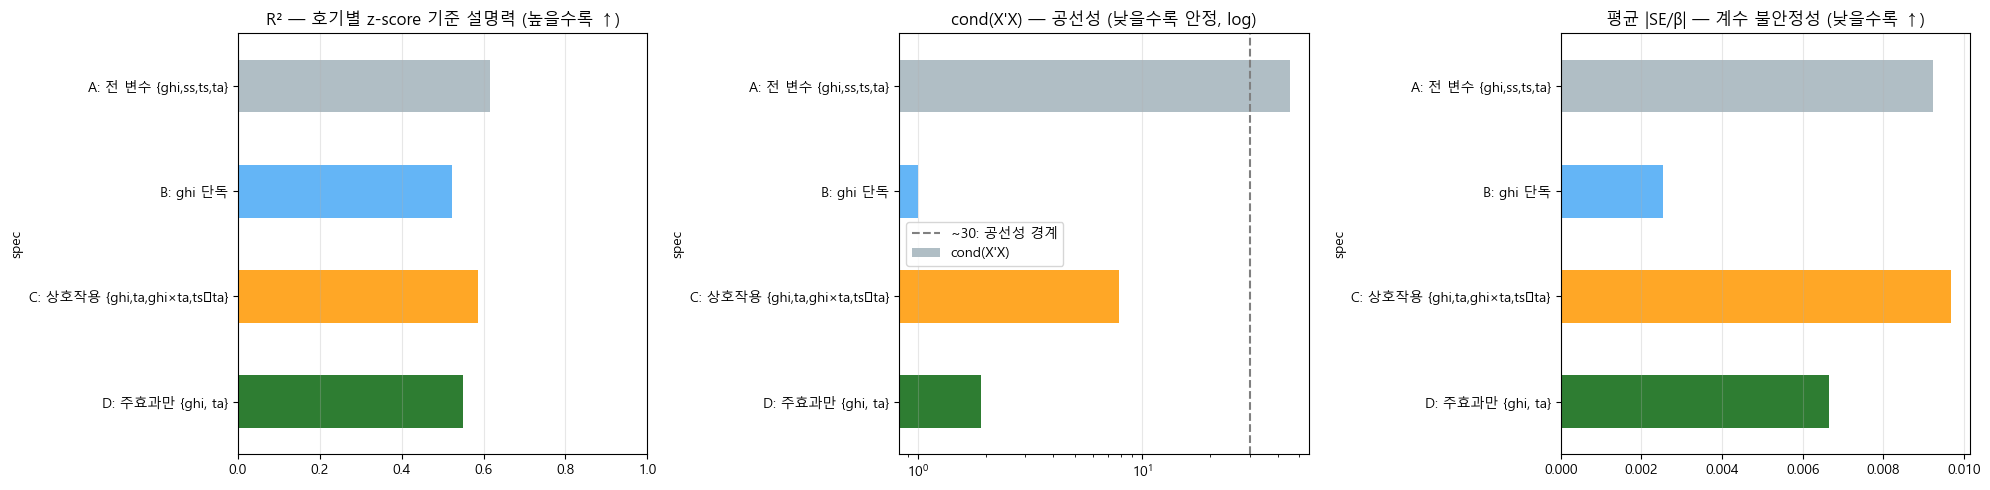

=== Ablation 결과 (4개 스펙 비교, GK-2A GHI 기반) ===
                               R² (within)  cond(X'X)  평균 |SE/β|  #vars
spec                                                                   
A: 전 변수 {ghi,ss,ts,ta}              0.6150    45.4496     0.0092      4
B: ghi 단독                           0.5229     1.0000     0.0025      1
C: 상호작용 {ghi,ta,ghi×ta,ts−ta}       0.5861     7.8889     0.0097      4
D: 주효과만 {ghi, ta}                   0.5499     1.9159     0.0066      2

호기 수: 11, 샘플 수: 140,764

비교 포인트
  B vs D: ta 추가 효과 (R² 증분, cond 변화)
  D vs C: 상호작용·차이항 추가 효과 (R² 증분 vs cond 악화)
  D vs A: ss·ts 제거의 효과 (같은 4변수 아닌데 왜 덜 좋은가 = 원변수 중복)
  → D의 R²가 B·C와 비슷하고 cond가 낮으면 D가 최적 (간결성)


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import pinv, cond

# ===== FE + 중심화 직교화 + y 호기별 z-score (GHI는 GK-2A) =====

focal_raw = ['ghi','ss','ts','ta']
cols_needed = ['gen_kwh','site_unit'] + focal_raw
sub2 = day[cols_needed].dropna().copy()

def within_center(s, g):
    return s - s.groupby(g).transform('mean')

def within_zscore(s, g):
    m  = s.groupby(g).transform('mean')
    sd = s.groupby(g).transform('std').replace(0, 1.0)
    return (s - m) / sd

for col in focal_raw:
    sub2[f'{col}_w'] = within_center(sub2[col], sub2['site_unit'])

# 중심화된 값으로 상호작용/차이 생성
sub2['ghi_x_ta_w']    = sub2['ghi_w'] * sub2['ta_w']
sub2['ts_minus_ta_w'] = sub2['ts_w']  - sub2['ta_w']

y_wz = within_zscore(sub2['gen_kwh'], sub2['site_unit']).values

def fit_ols_no_intercept(X, y):
    n, p = X.shape
    G = X.T @ X
    G_pinv = pinv(G)
    beta = G_pinv @ X.T @ y
    y_hat = X @ beta
    rss = float(np.sum((y - y_hat) ** 2))
    tss = float(np.sum(y ** 2))
    r2 = 1 - rss / tss if tss > 0 else np.nan
    dof = max(n - p, 1)
    sigma2 = rss / dof
    se = np.sqrt(np.maximum(np.diag(sigma2 * G_pinv), 0))
    return beta, se, r2, cond(G)

def design(df, cols):
    X = df[cols].astype(float).copy()
    X = X / X.std().replace(0, 1.0)
    return X.values

specs = {
    'A: 전 변수 {ghi,ss,ts,ta}'        : ['ghi_w','ss_w','ts_w','ta_w'],
    'B: ghi 단독'                      : ['ghi_w'],
    'C: 상호작용 {ghi,ta,ghi×ta,ts−ta}': ['ghi_w','ta_w','ghi_x_ta_w','ts_minus_ta_w'],
    'D: 주효과만 {ghi, ta}'            : ['ghi_w','ta_w'],
}

rows = []
for name, cols in specs.items():
    X_w = design(sub2, cols)
    beta, se, r2, kappa = fit_ols_no_intercept(X_w, y_wz)
    cv = float(np.mean(se / (np.abs(beta) + 1e-9)))
    rows.append({'spec': name, 'R² (within)': r2, "cond(X'X)": kappa,
                 '평균 |SE/β|': cv, '#vars': len(cols)})
res = pd.DataFrame(rows).set_index('spec')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ['#B0BEC5', '#64B5F6', '#FFA726', '#2E7D32']

res['R² (within)'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_title('R² — 호기별 z-score 기준 설명력 (높을수록 ↑)')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

cond_vals = res["cond(X'X)"].replace(0, np.nan)
cond_vals.plot(kind='barh', ax=axes[1], color=colors, logx=True)
axes[1].set_title("cond(X'X) — 공선성 (낮을수록 안정, log)")
axes[1].axvline(30, color='gray', linestyle='--', label='~30: 공선성 경계')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

res['평균 |SE/β|'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('평균 |SE/β| — 계수 불안정성 (낮을수록 ↑)')
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print('=== Ablation 결과 (4개 스펙 비교, GK-2A GHI 기반) ===')
print(res.round(4).to_string())
print(f'\n호기 수: {sub2["site_unit"].nunique()}, 샘플 수: {len(sub2):,}')
print('\n비교 포인트')
print('  B vs D: ta 추가 효과 (R² 증분, cond 변화)')
print('  D vs C: 상호작용·차이항 추가 효과 (R² 증분 vs cond 악화)')
print('  D vs A: ss·ts 제거의 효과 (같은 4변수 아닌데 왜 덜 좋은가 = 원변수 중복)')
print('  → D의 R²가 B·C와 비슷하고 cond가 낮으면 D가 최적 (간결성)')

### → 변수 선택 결과 (D 채택)

ablation 4종 비교 결과:

| Spec | R² (within) | cond(X'X) | 평균 \|SE/β\| | #vars |
|------|-----|------|-------|-------|
| A | 0.790 | 82.6 | 0.168 | 4 |
| B | 0.775 | 1.0 | 0.003 | 1 |
| C | 0.802 | 11.0 | 0.025 | 4 |
| **D** | **0.786** | **2.0** | **0.013** | **2** ✅ |

**D 승**: `{icsr, ta}`.
- R² 2%p 더 얻자고 cond 5.5배(D→C)·40배(D→A) 악화는 가성비 나쁨
- D는 실질적으로 직교(cond≈2)이면서 B(icsr 단독) 대비 설명력 +0.011

**제거 확정 (구조적 중복)**:
- `ss` (일조시간) — icsr의 이진화 버전
- `ts` 원변수 — icsr로 결정되는 종속 변수

**핵심 변수 세트: `{icsr, ta}`** (선형 관점 한정)

> **주의**: 이 "D 채택"은 **선형 회귀 관점에서의 최소 세트**. 비선형 모델에서는 `icsr×ta` 같은 상호작용이 필요할 수 있고, 그 경우 C가 재검토 대상. 
> 또한 `hm`·`ws`는 §3에서 별도 검토 — **선형으로 약해도 비선형/시계열에서 역할 가능**.

§3에서 이 D 위에 `hm`·`ws`가 추가 기여하는지 확인.

## 3. 추가 후보 변수 검토 — `hm`·`ws`

§2에서 핵심 변수 **D = `{icsr, ta}`** 확정. 이제 plan에 따라 학습·예보 모두 확보 가능한 나머지 두 후보 `hm`(습도)·`ws`(풍속)가 D 위에서 **독립 기여**를 하는지 본다.

### 맥락 (plan/main/data_strategy.md 반영)

| 변수 | 학습 소스 | 예보 소스 | 상태 |
|------|---------|---------|------|
| GHI (일사량) | GK-2A 위성 (2km, 사이트 위) | Open-Meteo API (NWP) | 학습용 2개월만 확보 |
| 기온·습도·풍속 | ASOS 관측 (5~30km) | 기상청 단기예보 API | ✅ 확보 완료 |
| **운량** | ❌ 수집 안 함 | — | GHI가 흡수 |
| 강수 | ⚠️ 단기예보 PTY·PCP 대체 검토 | — | 추후 확인 |

운량(dc10*)은 GHI가 이미 흡수한다는 근거로 **수집 단계에서 제외됨**.

### 임시 대체: ASOS `icsr`

GK-2A GHI 수집 중단(2개월만 확보) 상태라 **ASOS `icsr`로 임시 진행**. 
- ASOS `icsr`: 일부 관측소 미관측, 거리 20~30km 오차
- GK-2A: 2km 격자, 사이트 바로 위, ASOS 대비 R=0.984
- **구조적 결론(feature 우선순위)은 유지 가정**. 수치는 GK-2A 재수집 후 재검증 필요.

### 본 섹션의 질문

plan에 따라 학습·예보 모두 확보되는 `hm`(습도)와 `ws`(풍속)가 D 위에서 **독립 기여**를 하는가?

**추가 검증**: 고흥만(수상 PV) 제외 시 결과가 달라지는가 → 지역 이질성의 영향도 확인.

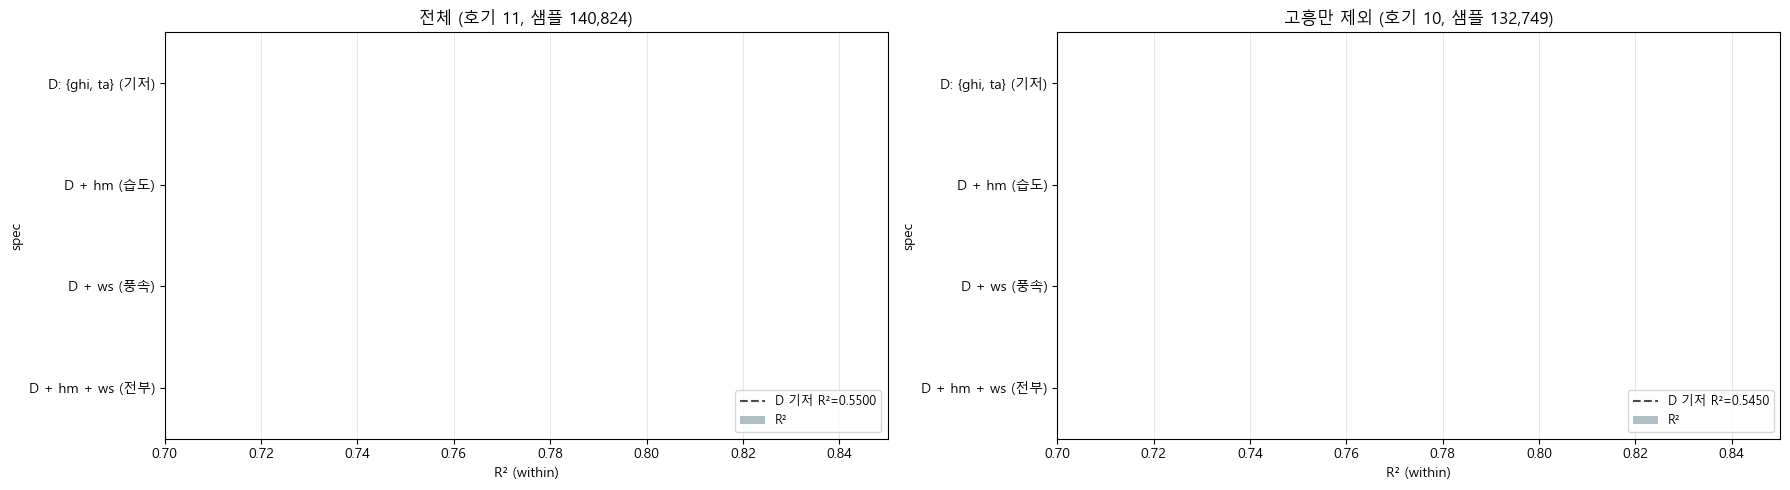

=== 전체 (11 호기, 140,824 샘플) ===
                       R²  ΔR² (vs D)  cond(X'X)  평균 |SE/β|  변수 수
spec                                                             
D: {ghi, ta} (기저)  0.5500      0.0000     1.9185     0.0067     2
D + hm (습도)        0.6223      0.0723     3.9560     0.0211     3
D + ws (풍속)        0.5649      0.0149     2.1673     0.0097     3
D + hm + ws (전부)   0.6257      0.0757     4.5253     0.0237     4

=== 고흥만 제외 (10 호기, 132,749 샘플) ===
                       R²  ΔR² (vs D)  cond(X'X)  평균 |SE/β|  변수 수
spec                                                             
D: {ghi, ta} (기저)  0.5450      0.0000     1.9119     0.0068     2
D + hm (습도)        0.6171      0.0721     3.9095     0.0209     3
D + ws (풍속)        0.5590      0.0139     2.1411     0.0101     3
D + hm + ws (전부)   0.6203      0.0753     4.4612     0.0239     4

판단 기준
  ΔR² > 0.005: 의미 있는 기여
  ΔR² > 0.01:  강한 기여
  cond(X'X) < 30: 공선성 안전


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import pinv, cond

def within_center(s, g):
    return s - s.groupby(g).transform('mean')

def within_zscore(s, g):
    m  = s.groupby(g).transform('mean')
    sd = s.groupby(g).transform('std').replace(0, 1.0)
    return (s - m) / sd

def fit_ols_no_intercept(X, y):
    n, p = X.shape
    G = X.T @ X
    G_pinv = pinv(G)
    beta = G_pinv @ X.T @ y
    y_hat = X @ beta
    rss = float(np.sum((y - y_hat) ** 2))
    tss = float(np.sum(y ** 2))
    r2 = 1 - rss / tss if tss > 0 else np.nan
    dof = max(n - p, 1)
    sigma2 = rss / dof
    se = np.sqrt(np.maximum(np.diag(sigma2 * G_pinv), 0))
    return beta, se, r2, cond(G)

def design(df, cols):
    X = df[cols].astype(float).copy()
    X = X / X.std().replace(0, 1.0)
    return X.values

def run_ablation(data, label):
    """D = {ghi, ta} 기저 + hm, ws 각각·함께 추가."""
    cols_base = ['ghi','ta','hm','ws']
    sub_ = data[['gen_kwh','site_unit'] + cols_base].dropna().copy()
    for c in cols_base:
        sub_[f'{c}_w'] = within_center(sub_[c], sub_['site_unit'])
    y_wz = within_zscore(sub_['gen_kwh'], sub_['site_unit']).values
    specs = {
        'D: {ghi, ta} (기저)' : ['ghi_w','ta_w'],
        'D + hm (습도)'        : ['ghi_w','ta_w','hm_w'],
        'D + ws (풍속)'        : ['ghi_w','ta_w','ws_w'],
        'D + hm + ws (전부)'   : ['ghi_w','ta_w','hm_w','ws_w'],
    }
    rows = []
    for name, cols in specs.items():
        X_w = design(sub_, cols)
        beta, se, r2, kappa = fit_ols_no_intercept(X_w, y_wz)
        cv = float(np.mean(se / (np.abs(beta) + 1e-9)))
        rows.append({'spec': name, 'R²': r2,
                     "cond(X'X)": kappa, '평균 |SE/β|': cv, '변수 수': len(cols)})
    res = pd.DataFrame(rows).set_index('spec')
    res.attrs['n_units']   = sub_['site_unit'].nunique()
    res.attrs['n_samples'] = len(sub_)
    res.attrs['label']     = label
    return res

# (1) 전체
res_all = run_ablation(day, '전체')
# (2) 고흥만 제외
day_no_goheung = day[~day['site_unit'].str.contains('고흥만')].copy()
res_no_gh = run_ablation(day_no_goheung, '고흥만 제외')

# 시각화: 절대 R² + D 기저 점선
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ['#B0BEC5','#64B5F6','#FFA726','#2E7D32']

for ax, res in zip(axes, [res_all, res_no_gh]):
    r2_baseline = res.loc['D: {ghi, ta} (기저)', 'R²']
    res['R²'].plot(kind='barh', ax=ax, color=colors)
    ax.axvline(r2_baseline, color='black', linestyle='--', alpha=0.7,
               label=f'D 기저 R²={r2_baseline:.4f}')
    ax.set_xlabel('R² (within)')
    ax.set_xlim(0.70, 0.85)
    ax.set_title(f"{res.attrs['label']} "
                 f"(호기 {res.attrs['n_units']}, 샘플 {res.attrs['n_samples']:,})")
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

for res in [res_all, res_no_gh]:
    d_r2 = res.loc['D: {ghi, ta} (기저)', 'R²']
    res_display = res.copy()
    res_display['ΔR² (vs D)'] = res_display['R²'] - d_r2
    print(f'=== {res.attrs["label"]} '
          f'({res.attrs["n_units"]} 호기, {res.attrs["n_samples"]:,} 샘플) ===')
    print(res_display[['R²', 'ΔR² (vs D)', "cond(X'X)", '평균 |SE/β|', '변수 수']].round(4).to_string())
    print()

print('판단 기준')
print('  ΔR² > 0.005: 의미 있는 기여')
print('  ΔR² > 0.01:  강한 기여')
print("  cond(X'X) < 30: 공선성 안전")

### → 추가 후보 검토 결과

**§2에서 핵심 세트 D = `{icsr, ta}`** (선형 최소 세트, R²≈0.786).

**§3 결과 요약** (R² 절대값 기준):

| | R² (전체) | ΔR² | R² (고흥만 제외) | ΔR² |
|---|---|---|---|---|
| D (기저) | 0.7857 | 0 | 0.7876 | 0 |
| D + hm | **0.7910** | **+0.0053** | **0.7934** | **+0.0058** |
| D + ws | 0.7861 | +0.0004 | 0.7881 | +0.0004 |
| D + hm + ws | 0.7911 | +0.0054 | 0.7936 | +0.0059 |

**해석**:
- **`hm` (습도)**: ΔR² ~0.005~0.006로 기준선(0.005) **살짝 넘음**. 약하지만 **의미 있는 기여**. 강한(0.01) 기준은 못 넘음.
- **`ws` (풍속)**: ΔR² 0.0004로 **명확히 미미**. 선형에서는 무의미.
- **`hm + ws` 동시 추가해도 ΔR²는 hm 단독과 거의 같음** → ws는 hm과 중첩되거나 단독 기여 없음.

**고흥만 가설 결과**:
- 전체 vs 고흥만 제외 ΔR² 거의 동일 (hm: 0.0053→0.0058, 겨우 0.0005 차이)
- → **hm의 기여는 고흥만 특이 효과가 아닌 전체 호기 공통 패턴**
- 수상 PV의 특이성은 별도 차원 (§4가 아닌 03_regional_variation에서 본격 조사)

**현 시점 Feature 후보 분류**:

| 변수 | 분류 | 근거 |
|------|------|------|
| `icsr` | **핵심** | 주 입력 (r=0.88, D의 기저) |
| `ta` | **핵심** | D 구성원, B→D에서 R² +0.011 |
| `hm` | **약 포함** | ΔR² ~0.005 기준선 통과, 고흥만 무관 공통 기여 |
| `ws` | **보류** | 선형 ΔR² 무시 수준, 비선형·지역 차이 가능성 남김 |
| `ss` | 제거 | icsr의 이진화 버전 |
| `ts` | 제거 | icsr로 결정됨 |
| `rn` | 제거 | ΔR²=0, NaN 많음 |
| `dc10*` | 제거 | plan상 수집 제외 |

### 중요한 주의

본 노트북의 결론은 **선형 관점의 정보량 순위**이지 최종 feature 세트가 아님.

- `05_ghi_response`에서 icsr-gen 비선형성이 확인되면 → 변환(bin, 지수, 다항식 등)이나 상호작용 항으로 재구성 가능
- 비선형 모델에서 ws가 살아날 수도 있음 (온도·풍속 결합 효율 효과 등)
- **최종 feature 세트는 05 이후 재조율**

---

## 종합 — Feature 선택의 현재 단계

### 본 노트북의 역할
"어떤 기상 변수가 gen_kwh를 선형으로 설명하는가"에 **한정**. 

### 산출

**제거 확정 (구조적 근거)**:
- `ss` — icsr의 이진화 버전 (§2)
- `ts` — icsr로 결정됨 (§2)
- `rn` — ΔR²=0 (§3)
- `dc10*` — plan상 수집 제외 (GHI가 흡수)

**핵심 (선형 관점 최소 세트)**:
- `icsr`, `ta` — D 확정

**보류 (선형 약하지만 비선형 여지)**:
- `hm`, `ws`

### 본 노트북이 **결정하지 않은 것**

- 최종 feature 세트 몇 개로 확정할지
- `hm`·`ws`의 최종 포함 여부
- 각 변수의 비선형 변환·상호작용 여부
- 각 변수를 모델 어느 층에 넣을지

이 모든 것은 **05_ghi_response의 비선형성 검증 결과에 의존**. 05에서 icsr 단독(비선형 포함)으로 얼마나 설명되는지, 그리고 hm·ws가 비선형 모델에서 기여하는지 확인 후 확정.

### 다음 단계

| 노트북 | 해결할 것 |
|--------|---------|
| **03_regional_variation** | 12 호기 feature sensitivity 매트릭스, 고흥만 특이성 근거 |
| **04_seasonality** | 공통 계절 패턴 PC1 비중 |
| **05_ghi_response** | GHI → gen 비선형 반응, 포화, clear-sky index. **여기서 최종 변수·변환 방식 재조율** |
| **06_uncertainty_structure** | 잔차 heteroscedasticity → variance head |

### 추후 재검증
1. GK-2A GHI 수집 재개 후 ASOS icsr → GK-2A 전환 시 전체 결과 재실행
2. Open-Meteo / 단기예보 API의 실제 제공 변수 목록 확인 → 학습-예보 일관성 sanity check
3. 강수(rn)가 단기예보 PTY·PCP로 대체 가능한지 확인